# ZINC DB에서 농약 찾기 (search algorithm)
1. linear search (일일히 모두 비교.)
2. hash search (hash table을 만들어서 데이터 저장. 새로운 데이터가 왔을 때, hash 함수를 이용해서 탐색.)
3. binary search (정렬된 리스트에서 절반만 탐색에 사용하는 방법.)

### 누가 제일 빠를까? (왜 그럴까?)

In [ ]:
import pandas as pd
import glob
import time

# 농약 로드
pesticides = pd.read_csv("PubChem_Agrochemical.csv")

In [ ]:
#농약 csv 파일의 컬럼 확인
pesticides.columns

In [ ]:
#비교할 zinc DB (A*.txt로 시도한 이후 전체에 대해서 수행)
zinc_files = sorted(glob.glob("./zinc_db/A*.txt"))

# Linear search

In [ ]:
#linear search
pesticides_smi = pesticides['smiles'].to_list()

In [ ]:
pesticides_smi

In [ ]:
found = []
start = time.time()

for i, f in enumerate(zinc_files):
    zinc = pd.read_csv(f, sep='\t', usecols=['smiles','logp'])
    for smi in zinc['smiles']:
        if smi in pesticides_smi:
            found.append(smi)

    print(f"[{i+1}/{len(zinc_files)}] 발견: {len(found)}개 | {time.time()-start:.1f}초")

# 결과 저장
pd.DataFrame({'smiles': found}).to_csv("found_results.csv", index=False)
print(f"완료! 총 {len(found)}개 발견")

# Hash search

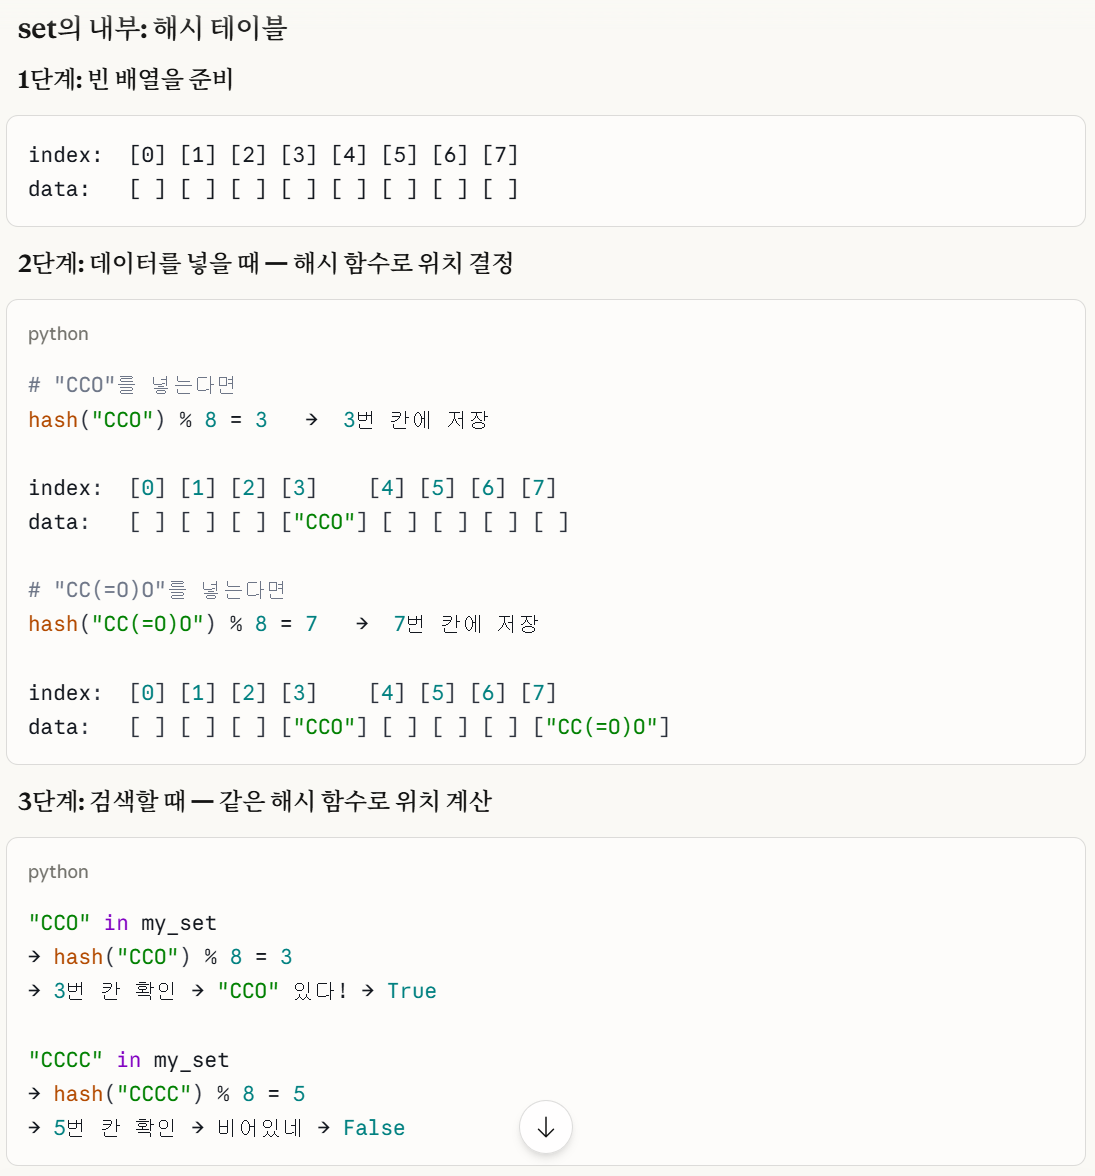
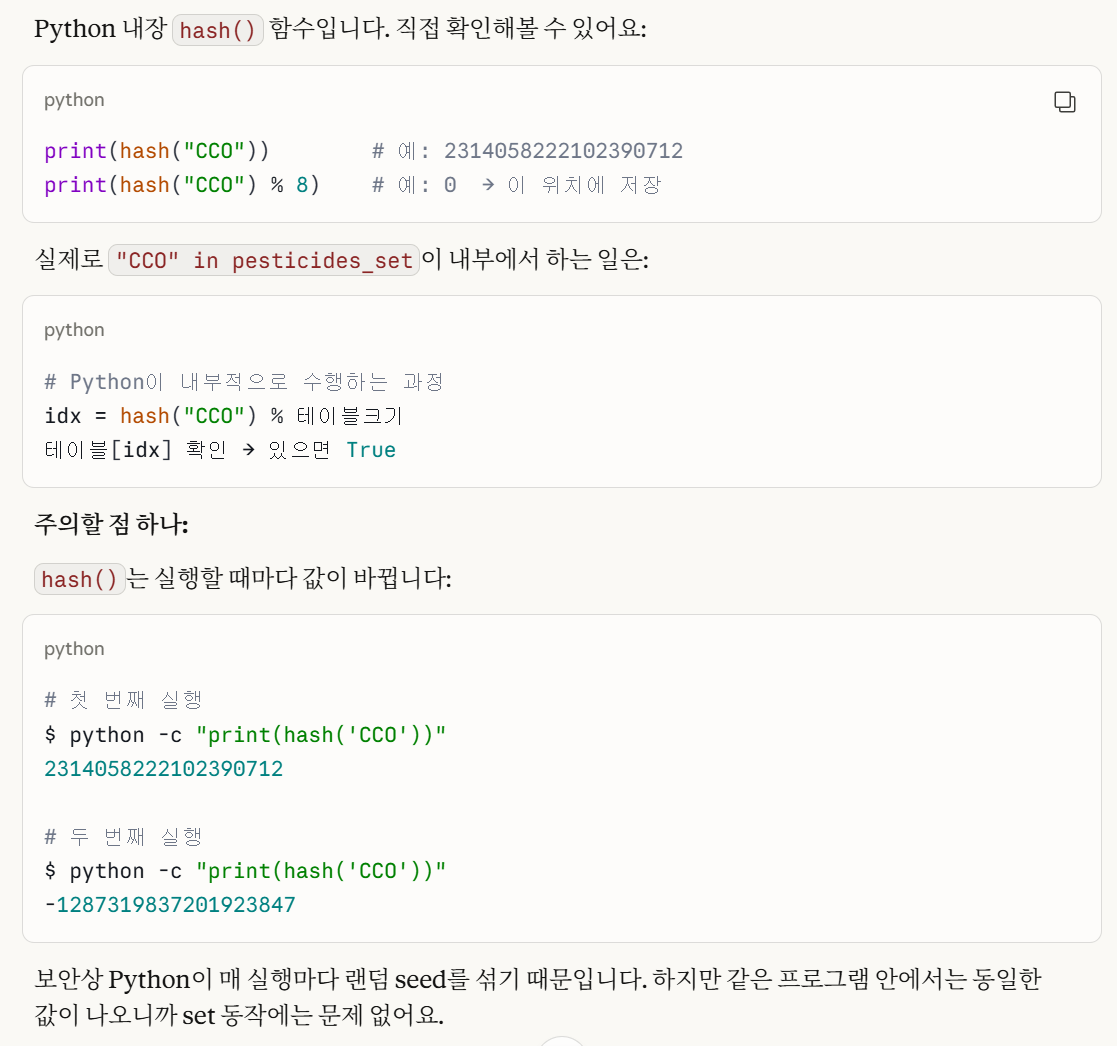

In [ ]:
pesticides_hash_table = set(pesticides_smi)

In [ ]:

found = []
start = time.time()

for i, f in enumerate(zinc_files):
    zinc = pd.read_csv(f, sep='\t', usecols=['smiles','logp'])
    for smi in zinc['smiles']:
        if smi in pesticides_hash_table:
            found.append(smi)

    print(f"[{i+1}/{len(zinc_files)}] 발견: {len(found)}개 | {time.time()-start:.1f}초")

# 결과 저장
pd.DataFrame({'smiles': found}).to_csv("found_results.csv", index=False)
print(f"완료! 총 {len(found)}개 발견")

# Binary search

In [ ]:
# binary search
pesticides_binary = sorted(pesticides_smi)

In [ ]:
pesticides_binary

In [ ]:
import bisect

bisect.bisect_left(pesticides_binary, 'CCCC')

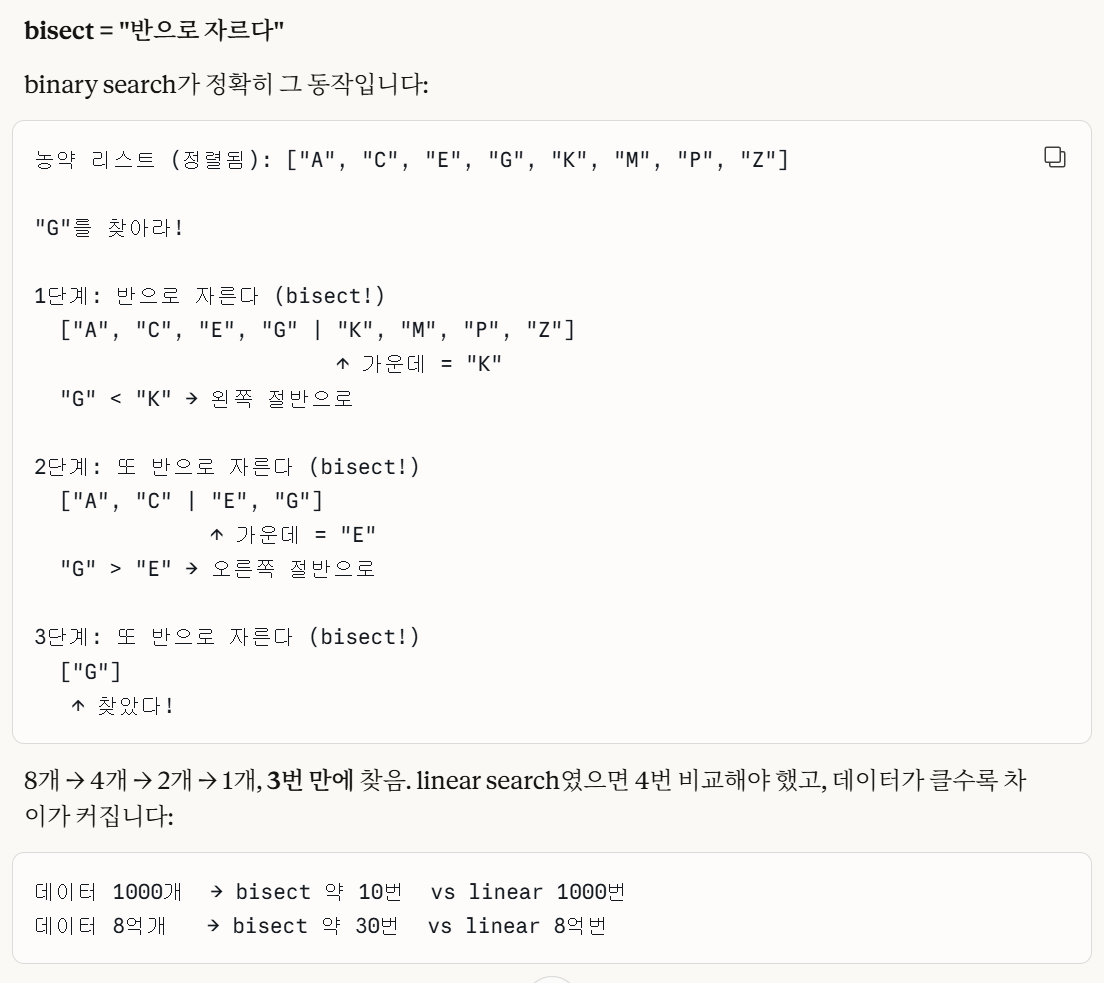

# 숫자도 아닌데, 어떻게 문자를 부등호로 비교할까?
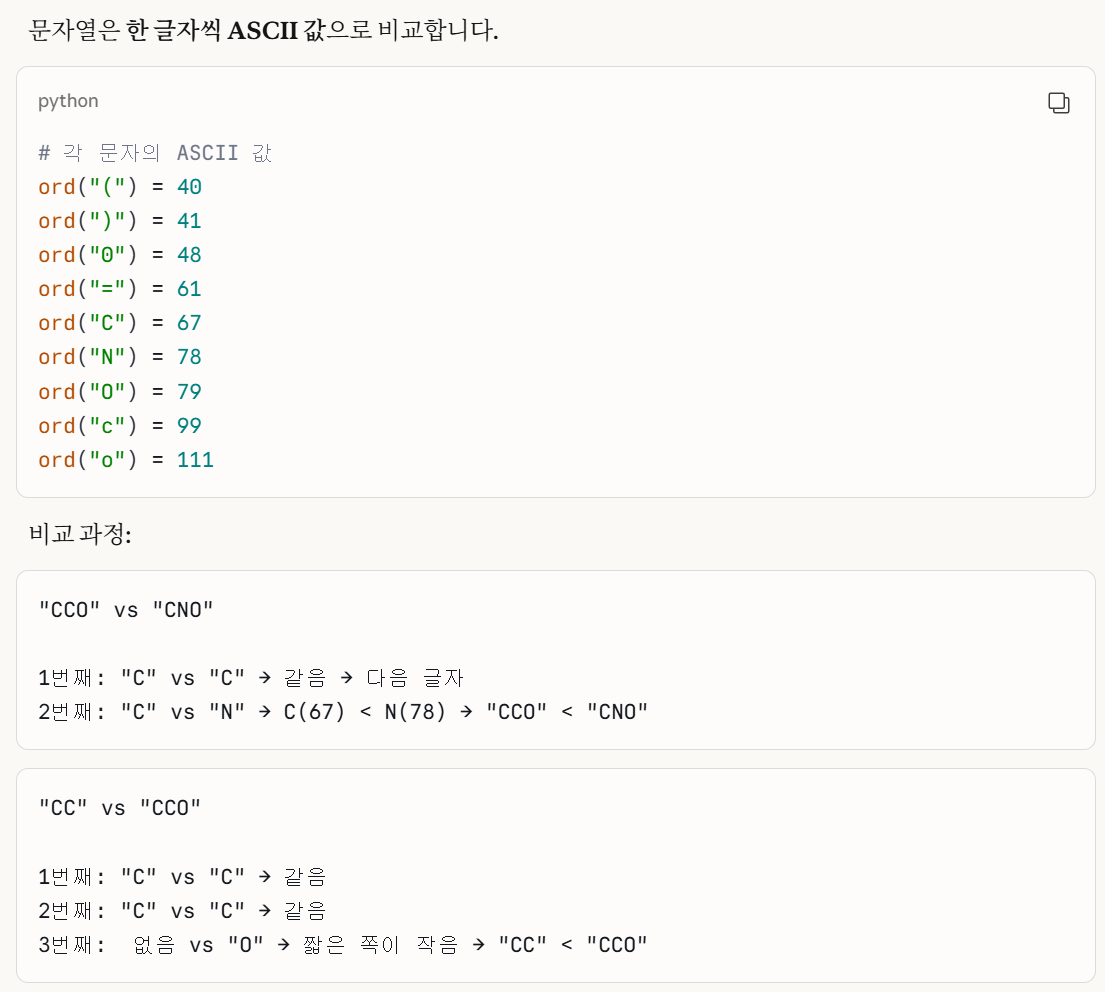

# 문자 비교할때, 대소문자 차이도 다르게 인지하는 이유
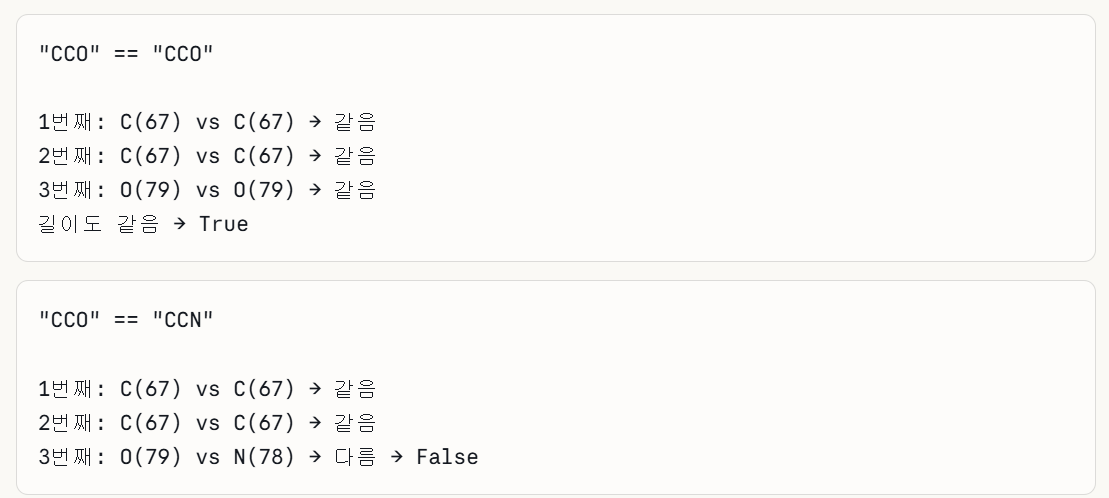

In [ ]:
def binary_search(sorted_list, target):
    idx = bisect.bisect_left(sorted_list, target)
    return idx < len(sorted_list) and sorted_list[idx] == target

In [ ]:
found = []
start = time.time()

for i, f in enumerate(zinc_files):
    zinc = pd.read_csv(f,  sep='\t', usecols=['smiles','logp'])
    for smi in zinc['smiles']:
        if binary_search(pesticides_binary, smi):
            found.append(smi)

    print(f"[{i+1}/{len(zinc_files)}] 발견: {len(found)}개 | {time.time()-start:.1f}초")

print(f"완료! 총 {len(found)}개 발견")